In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the retail sales dataset

df = pd.read_csv("../data/retail_sales_dataset.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (1000, 24)


,Transaction ID,Date,Gender,Age,Age Group,Product Category,Quantity,Price per Unit,Total Amount,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Min_age,Max_age,Avg_age,Total Sales Revenue,Average Order value,Category,Sales
0,1,11/24/2023,Male,34,Middle Age,Beauty,3,50,150,NaN,...,NaN,NaN,NaN,18.0,64.0,41.0,456000.0,456.0,Electronics,156905.0
1,2,2/27/2023,Female,26,Adolescent,Clothing,2,500,1000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Clothing,155580.0
2,3,1/13/2023,Male,50,Middle Age,Electronics,1,30,30,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Beauty,143515.0
3,4,5/21/2023,Male,37,Middle Age,Clothing,1,500,500,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,5/6/2023,Male,30,Adolescent,Beauty,2,50,100,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Initial inspection of the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (1000, 24)

Column Names:
['Transaction ID', 'Date', 'Gender', 'Age', 'Age Group', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Min_age', 'Max_age', 'Avg_age', 'Total Sales Revenue', 'Average Order value', ' Category', 'Sales']

Data Types:
Transaction ID           int64
Date                    object
Gender                  object
Age                      int64
Age Group               object
Product Category        object
Quantity                 int64
Price per Unit           int64
Total Amount             int64
Unnamed: 9             float64
Unnamed: 10            float64
Unnamed: 11            float64
Unnamed: 12            float64
Unnamed: 13            float64
Unnamed: 14            float64
Unnamed: 15            float64
Unnamed: 16            float64
Min_age                float64
Max_age                float64
Avg_age       

In [4]:
# Check non-null values in every column

column_summary = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Values": df.notnull().sum().values,
    "Null Values": df.isnull().sum().values
})

column_summary

,Column,Non-Null Values,Null Values
0,Transaction ID,1000,0
1,Date,1000,0
2,Gender,1000,0
3,Age,1000,0
4,Age Group,1000,0
5,Product Category,1000,0
6,Quantity,1000,0
7,Price per Unit,1000,0
8,Total Amount,1000,0
9,Unnamed: 9,0,1000


## Data Cleaning

The initial inspection revealed that the first 9 columns contain complete transaction-level data. Several additional columns contain either entirely missing values or isolated summary values that do not belong to individual transactions.

These columns appear to be export artifacts or summary information rather than useful transaction-level features. Therefore, they will be removed instead of being imputed, because filling these values would introduce incorrect information into the analysis.

The main transaction columns retained are:

- Transaction ID
- Date
- Gender
- Age
- Age Group
- Product Category
- Quantity
- Price per Unit
- Total Amount

In [5]:
# Keep only valid transaction-level columns

valid_columns = [
    "Transaction ID",
    "Date",
    "Gender",
    "Age",
    "Age Group",
    "Product Category",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

df = df[valid_columns].copy()

print("Dataset shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Dataset shape after cleaning: (1000, 9)

Missing values after cleaning:
Transaction ID      0
Date                0
Gender              0
Age                 0
Age Group           0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [6]:
# Convert Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"])

print("Data types after correction:")
print(df.dtypes)

Data types after correction:
Transaction ID               int64
Date                datetime64[ns]
Gender                      object
Age                          int64
Age Group                   object
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


In [7]:
# Descriptive statistics for numerical columns

numerical_columns = [
    "Transaction ID",
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

# Mean
mean_values = df[numerical_columns].mean()

# Median
median_values = df[numerical_columns].median()

# Mode
mode_values = df[numerical_columns].mode().iloc[0]

# Standard deviation
std_values = df[numerical_columns].std()

# Combine results into one table
descriptive_stats = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values,
    "Standard Deviation": std_values
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## Monthly Sales Trend

To understand how sales change over time, the transaction dates are grouped by month and the total sales revenue is calculated for each month.

A line chart is used to identify periods of higher and lower sales activity and to observe overall sales patterns.

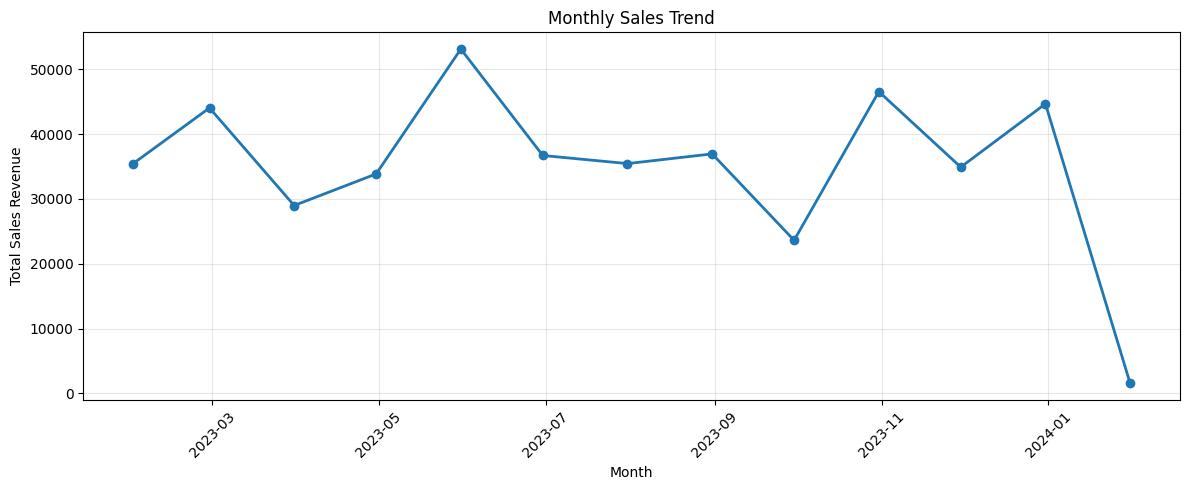

In [8]:
# Monthly sales trend

monthly_sales = (
    df.set_index("Date")
      .resample("ME")["Total Amount"]
      .sum()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

The monthly sales trend shows noticeable fluctuations throughout the period. Sales reached their highest level in June 2023 at approximately 53K, while October 2023 recorded a significant decline to around 24K.

Sales recovered strongly in November 2023 and January 2024. The very low sales value in February 2024 should be interpreted cautiously because the dataset contains limited transactions for that month and may not represent a complete month's activity.

Overall, the business shows fluctuating monthly performance rather than a consistent upward or downward trend.

## Quarterly Sales Trend

Quarterly aggregation provides a broader view of sales performance by reducing the effect of short-term monthly fluctuations. This helps identify which periods of the year generated the highest overall revenue.

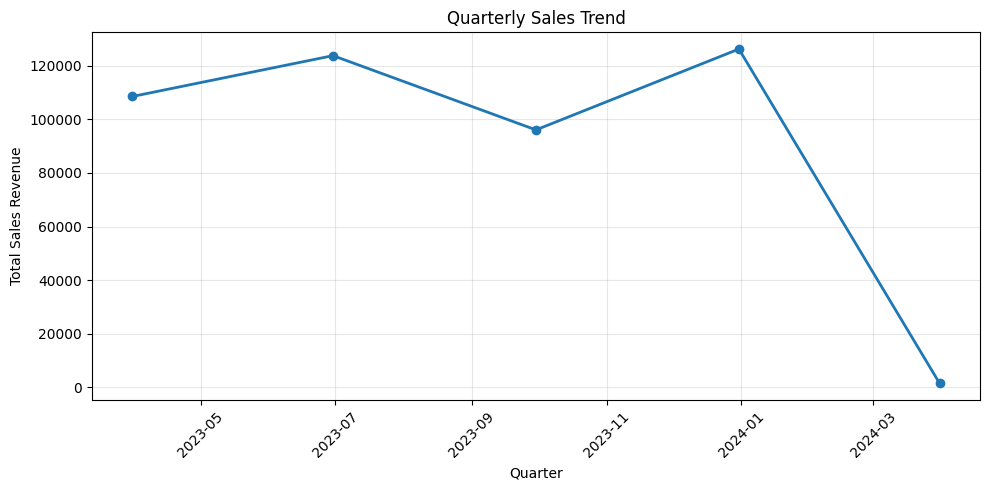

In [9]:
# Quarterly sales trend

quarterly_sales = (
    df.set_index("Date")
      .resample("QE")["Total Amount"]
      .sum()
)

plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

The quarterly sales trend shows that sales were strongest during the second and fourth quarters of the observed period. The highest quarterly revenue was recorded in Q4 2023 at approximately 126K, while Q2 2023 also performed strongly at around 124K.

Sales declined to approximately 96K in Q3 2023 before recovering in Q4. The low value for Q1 2024 should be interpreted cautiously because the dataset contains limited transactions for February 2024 and therefore does not represent a complete quarter.

Overall, the quarterly analysis indicates fluctuations in revenue and highlights Q4 2023 as the strongest period in the available data.

## Customer Demographics Analysis

Understanding customer demographics helps identify the types of customers contributing most to sales activity. We will analyse the distribution of customers across age groups and examine the gender breakdown.

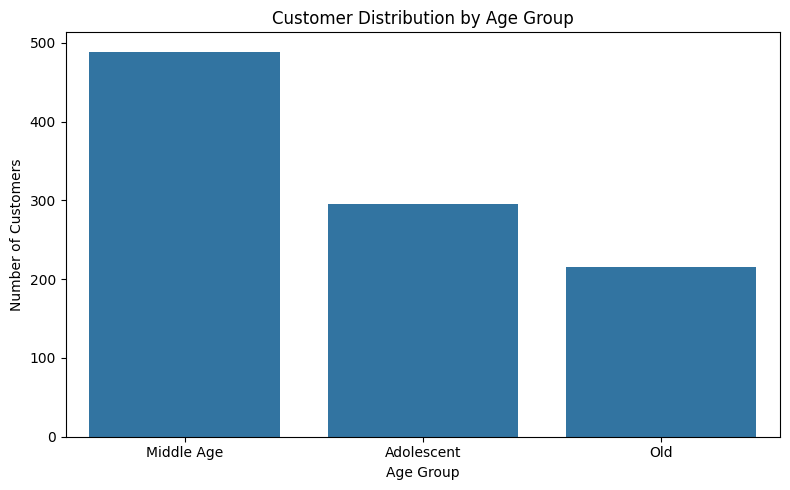

In [10]:
# Customer age group distribution

age_group_counts = df["Age Group"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

The age-group distribution shows that Middle Age customers form the largest customer segment, with approximately 487 customers. Adolescent customers are the second-largest group with around 295 customers, while Old customers account for approximately 218 customers.

This indicates that the retail business has a strong customer base among middle-aged consumers. Marketing campaigns can therefore prioritize products and offers that are relevant to this segment while continuing to develop strategies for younger and older customers.

## Gender Distribution

Gender distribution provides another view of the customer base and can help identify whether purchasing activity is concentrated more heavily among male or female customers.

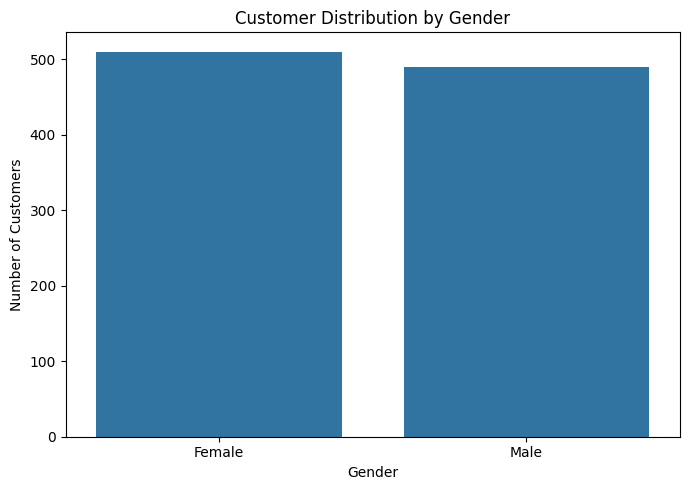

In [11]:
# Gender distribution

gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

The gender distribution is almost balanced, with female customers accounting for approximately 510 transactions and male customers accounting for approximately 490 transactions.

Female customers are slightly more represented in the dataset, but the difference is small. This suggests that the business has a relatively balanced customer base and marketing strategies should not be heavily focused on only one gender.

## Product Analysis

The dataset does not contain individual product names or product IDs. Therefore, product-level ranking cannot be performed reliably. Instead, sales performance is analysed at the Product Category level.

This approach allows us to identify which product categories generate the highest sales and revenue without introducing artificial product information.

In [12]:
# Sales performance by product category

category_sales = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

### Revenue by Product Category

The total revenue generated by each product category is visualised using a bar chart to compare category-level sales performance.

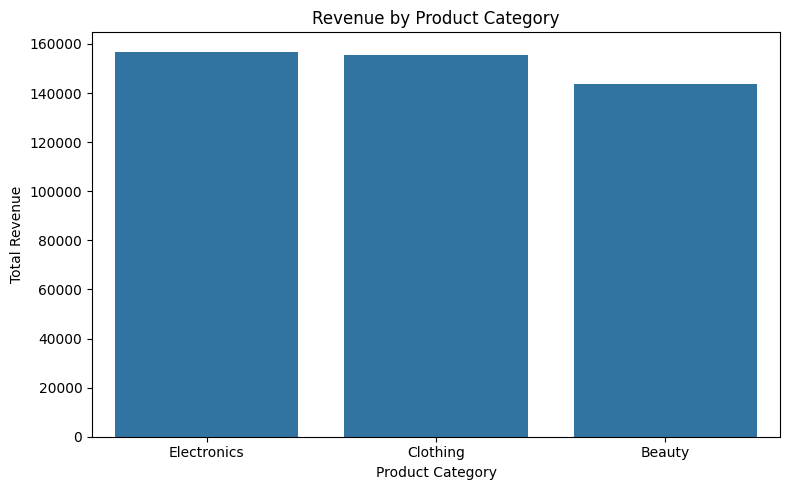

In [13]:
# Revenue by product category

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

### Observation

Electronics generated the highest total revenue at approximately ₹156,905, followed closely by Clothing at approximately ₹155,580. Beauty generated the lowest revenue at approximately ₹143,515.

The relatively small difference between the three categories indicates that revenue is reasonably well distributed across the product categories. Electronics can be prioritised for revenue-focused campaigns, while Beauty may benefit from targeted promotions to improve its contribution.

## Correlation Analysis

Correlation analysis helps identify the strength and direction of relationships between numerical variables. A heatmap is used to make these relationships easier to interpret.

A correlation value close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship. Values close to 0 indicate a weak linear relationship.

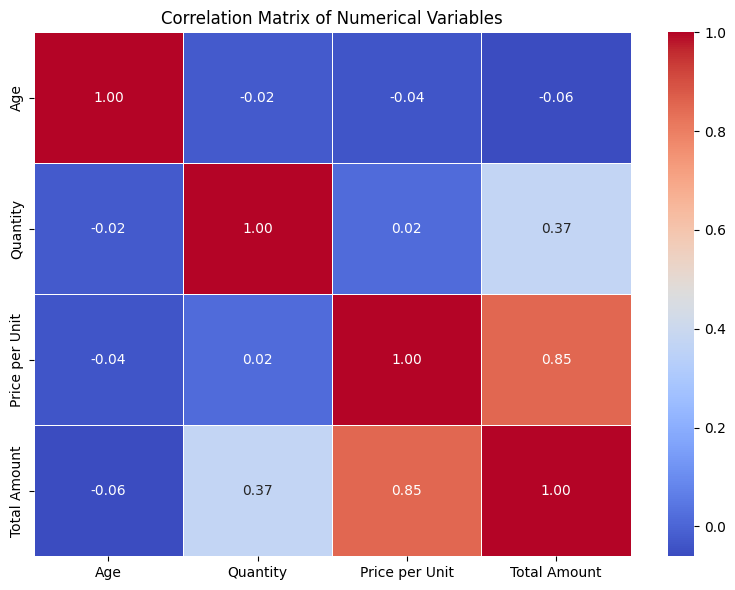

In [14]:
# Correlation matrix

numerical_data = df[
    ["Age", "Quantity", "Price per Unit", "Total Amount"]
]

correlation_matrix = numerical_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Observation

The correlation analysis shows a strong positive relationship between Price per Unit and Total Amount, with a correlation of 0.85. This is expected because higher-priced products generally contribute more to the total transaction value.

Quantity has a moderate positive correlation of 0.37 with Total Amount, indicating that purchasing more items tends to increase transaction revenue.

Age has almost no linear relationship with Total Amount (-0.06), while Age also shows negligible relationships with Price per Unit and Quantity. This suggests that customer age alone is not a strong indicator of transaction value in this dataset.

## Additional Visualization: Average Transaction Value by Age Group

Customer count alone does not show which age group generates higher-value transactions. Therefore, average transaction value is compared across age groups to identify differences in purchasing value.

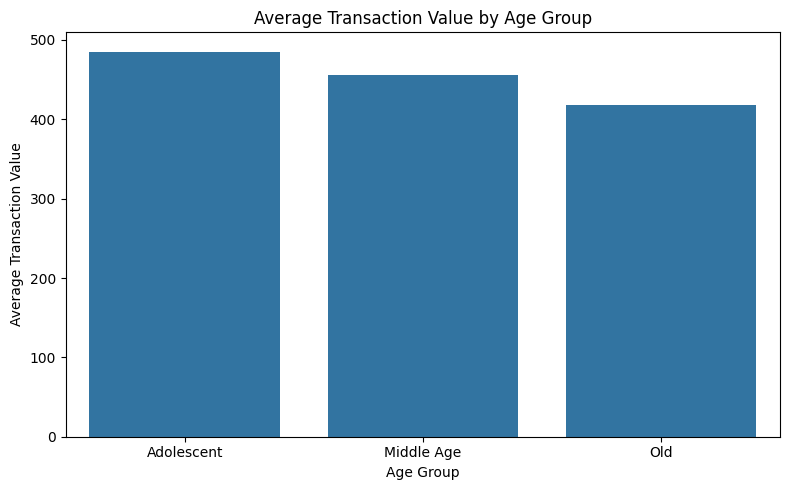

In [15]:
# Average transaction value by age group

avg_value_by_age = (
    df.groupby("Age Group")["Total Amount"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_value_by_age.index,
    y=avg_value_by_age.values
)

plt.title("Average Transaction Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Value")

plt.tight_layout()
plt.show()

### Observation

The average transaction value differs across age groups. Adolescent customers have the highest average transaction value at approximately ₹484, followed by Middle Age customers at around ₹455. Old customers have the lowest average transaction value at approximately ₹418.

An important insight is that although Middle Age customers represent the largest customer segment, Adolescent customers generate a higher average value per transaction. This suggests that customer volume and customer spending value are not necessarily the same, and younger customers could be targeted with higher-value product bundles and promotional offers.

# Conclusion and Business Recommendations

## Key Findings

1. **Sales performance fluctuates over time:** Monthly and quarterly sales show noticeable variations, with June 2023 and Q4 2023 being particularly strong periods.

2. **Middle Age customers form the largest customer segment:** Approximately 487 customers belong to the Middle Age group, making them the largest segment in the dataset.

3. **Female and male customers are almost equally represented:** The customer base is relatively balanced by gender, with female customers being slightly more numerous.

4. **Electronics generates the highest revenue:** Electronics generated approximately ₹156,905 in total revenue, followed closely by Clothing at approximately ₹155,580.

5. **Price has a strong relationship with transaction value:** Price per Unit has a strong positive correlation of 0.85 with Total Amount, while Quantity has a moderate positive correlation of 0.37.

6. **Younger customers show higher average transaction value:** Although Middle Age customers are the largest group, Adolescent customers have the highest average transaction value at approximately ₹484.

## Actionable Business Recommendations

### 1. Prioritize High-Performing Product Categories

Electronics generated the highest revenue and should receive continued inventory support and targeted promotional campaigns. Clothing should also remain a priority because its revenue is very close to Electronics.

### 2. Create Age-Specific Marketing Campaigns

Middle Age customers should remain an important target because they represent the largest customer segment. However, Adolescent customers should be targeted with higher-value bundles and promotional offers because they have the highest average transaction value.

### 3. Use Pricing and Bundling Strategies

Since Price per Unit has a strong positive relationship with Total Amount, the business can increase revenue by promoting premium products, product bundles, and cross-selling opportunities that increase the value of individual transactions.

## Dataset Limitation

The dataset does not contain individual product names or product IDs. Therefore, a true Top 10 Best-Selling Products analysis could not be performed. Product performance was instead analysed at the Product Category level without creating artificial product information.

Overall, the analysis demonstrates that sales performance, customer demographics, product categories, pricing, and transaction value can provide useful insights for improving retail marketing and revenue strategies.

In [16]:
# Save the cleaned dataset

df.to_csv("../data/retail_sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Cleaned dataset saved successfully!
Rows: 1000
Columns: 9


In [17]:
# FINAL PROJECT VERIFICATION

print("=" * 60)
print("RETAIL SALES EDA - FINAL VERIFICATION")
print("=" * 60)

print("\n1. Dataset Shape:")
print(df.shape)

print("\n2. Missing Values:")
print(df.isnull().sum().sum())

print("\n3. Duplicate Rows:")
print(df.duplicated().sum())

print("\n4. Data Types:")
print(df.dtypes)

print("\n5. Product Categories:")
print(df["Product Category"].value_counts())

print("\n6. Gender Distribution:")
print(df["Gender"].value_counts())

print("\n7. Age Group Distribution:")
print(df["Age Group"].value_counts())

print("\n8. Total Revenue:")
print(f"₹{df['Total Amount'].sum():,.2f}")

print("\n9. Average Transaction Value:")
print(f"₹{df['Total Amount'].mean():,.2f}")

print("\n10. Highest Revenue Category:")
category_revenue = df.groupby("Product Category")["Total Amount"].sum()
print(category_revenue.idxmax())

print("\n" + "=" * 60)
print("PROJECT VERIFICATION COMPLETED")
print("=" * 60)

RETAIL SALES EDA - FINAL VERIFICATION

1. Dataset Shape:
(1000, 9)

2. Missing Values:
0

3. Duplicate Rows:
0

4. Data Types:
Transaction ID               int64
Date                datetime64[ns]
Gender                      object
Age                          int64
Age Group                   object
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

5. Product Categories:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

6. Gender Distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64

7. Age Group Distribution:
Age Group
Middle Age    489
Adolescent    295
Old           216
Name: count, dtype: int64

8. Total Revenue:
₹456,000.00

9. Average Transaction Value:
₹456.00

10. Highest Revenue Category:
Electronics

PROJECT VERIFICATION COMPLETED
